# Final Statistical Analysis

This notebook contains the statistical analysis of the final benchmark datasets generated for the empirical comparison of Node.js, Bun and Deno.

The four processed datasets used in this notebook had already undergone benchmark-specific completeness and quality-control audits before analysis. The checks performed here are therefore limited to successful import, variable typing and factor ordering required for statistical analysis.

The analysis proceeds by dependent-variable family:

1. HTTP throughput and latency;
2. cold-start time;
3. file I/O performance; and
4. memory usage.

For each metric family, the analysis follows the methodology defined in Chapter 3:

- descriptive statistics;
- visual inspection;
- assumption checks;
- paired omnibus statistical testing;
- post-hoc paired comparisons where justified;
- effect sizes;
- 95% confidence intervals; and
- multiple-comparison adjustment where required.

Overall performance balance and literature-supported architectural interpretation are addressed only after the individual metric analyses have been completed.

In [3]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(readr)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




In [2]:
project_root <- if (
  dir.exists("data")
) {
  "."
} else {
  ".."
}

project_root

[1] ".."

In [3]:
http_final <- read_csv(
  file.path(
    project_root,
    "data",
    "processed",
    "http",
    "http_final_combined.csv"
  ),
  show_col_types = FALSE
)

cold_start_final <- read_csv(
  file.path(
    project_root,
    "data",
    "processed",
    "cold_start",
    "cold_start_final.csv"
  ),
  show_col_types = FALSE
)

file_io_final <- read_csv(
  file.path(
    project_root,
    "data",
    "processed",
    "file_io",
    "file_io_final.csv"
  ),
  show_col_types = FALSE
)

memory_final <- read_csv(
  file.path(
    project_root,
    "data",
    "processed",
    "memory",
    "memory_final.csv"
  ),
  show_col_types = FALSE
)

In [4]:
data.frame(
  dataset = c(
    "HTTP",
    "Cold start",
    "File I/O",
    "Memory"
  ),

  observations = c(
    nrow(http_final),
    nrow(cold_start_final),
    nrow(file_io_final),
    nrow(memory_final)
  )
)

dataset,observations
<chr>,<int>
HTTP,180
Cold start,90
File I/O,60
Memory,120


In [5]:
# Standard display order used throughout the analysis
runtime_levels <- c(
  "Node.js",
  "Bun",
  "Deno"
)

# HTTP dataset contains: Node.js, bun, deno
http_final <- http_final |>
  mutate(
    runtime = factor(
      runtime,
      levels = c(
        "Node.js",
        "bun",
        "deno"
      ),
      labels = runtime_levels
    ),

    workload = factor(
      workload,
      levels = c(
        "simple",
        "complex"
      ),
      labels = c(
        "Simple",
        "Complex"
      )
    ),

    connections = factor(
      connections,
      levels = c(
        10,
        50,
        100
      )
    )
  )

# Other datasets contain: node, bun, deno
cold_start_final <- cold_start_final |>
  mutate(
    runtime = factor(
      runtime,
      levels = c(
        "node",
        "bun",
        "deno"
      ),
      labels = runtime_levels
    )
  )

file_io_final <- file_io_final |>
  mutate(
    runtime = factor(
      runtime,
      levels = c(
        "node",
        "bun",
        "deno"
      ),
      labels = runtime_levels
    ),

    operation = factor(
      operation,
      levels = c(
        "read",
        "write"
      ),
      labels = c(
        "Read",
        "Write"
      )
    )
  )

memory_final <- memory_final |>
  mutate(
    runtime = factor(
      runtime,
      levels = c(
        "node",
        "bun",
        "deno"
      ),
      labels = runtime_levels
    ),

    workload = factor(
      workload,
      levels = c(
        "idle",
        "allocated"
      ),
      labels = c(
        "Idle",
        "Allocated"
      )
    )
  )

In [6]:
levels(http_final$runtime)
levels(cold_start_final$runtime)
levels(file_io_final$runtime)
levels(memory_final$runtime)

[1] "Node.js" "Bun"     "Deno"

[1] "Node.js" "Bun"     "Deno"

[1] "Node.js" "Bun"     "Deno"

[1] "Node.js" "Bun"     "Deno"

## 1. HTTP Performance Analysis

The HTTP experiment evaluates runtime performance under two workload types:

- **Simple workload:** a minimal fixed JSON response intended to establish baseline native HTTP-serving performance.
- **Complex workload:** a controlled dynamic request-processing task involving JSON parsing, validation, item iteration, arithmetic processing and dynamic response serialisation.

Each workload was tested at three concurrent-connection levels:

- 10 connections;
- 50 connections; and
- 100 connections.

Ten repeated observations were collected for each runtime, workload and connection-level combination.

The primary HTTP throughput metric is requests completed per second. Higher values indicate greater throughput.

The principal latency measures considered for inferential analysis are:

- mean latency, representing typical request latency; and
- p99 latency, representing tail-latency behaviour.

Other recorded latency measures remain available as supporting descriptive information.

In [7]:
http_throughput_summary <- http_final |>
  group_by(
    workload,
    connections,
    runtime
  ) |>
  summarise(
    n = n(),

    mean_rps = mean(
      requests_per_second
    ),

    median_rps = median(
      requests_per_second
    ),

    sd_rps = sd(
      requests_per_second
    ),

    iqr_rps = IQR(
      requests_per_second
    ),

    min_rps = min(
      requests_per_second
    ),

    max_rps = max(
      requests_per_second
    ),

    .groups = "drop"
  )

http_throughput_summary

workload,connections,runtime,n,mean_rps,median_rps,sd_rps,iqr_rps,min_rps,max_rps
<fct>,<fct>,<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Simple,10,Node.js,10,16859.00,16823.00,388.0141,444.7000,16192.27,17446.00
Simple,10,NA,20,19044.79,18578.94,1555.7340,1299.3150,16671.87,22207.34
Simple,50,Node.js,10,16025.44,15955.74,538.9635,477.7625,15065.34,16972.27
Simple,50,NA,20,19137.74,18868.40,864.8507,1026.0775,17838.67,21345.47
Simple,100,Node.js,10,15099.96,15398.67,1259.9088,581.8350,11643.34,16009.87
Simple,100,NA,20,18326.07,17926.74,1258.3791,766.7300,15794.80,20878.54
Complex,10,Node.js,10,12471.48,12340.14,259.9425,353.5350,12197.74,12902.47
Complex,10,NA,20,16611.15,16569.21,1647.3981,3063.9675,14371.00,18970.80
Complex,50,Node.js,10,11696.36,11769.07,227.1217,278.4000,11284.20,12008.07


In [8]:
# 95% confidence intervals (t-based)

http_throughput_summary <- http_final |>
  group_by(
    workload,
    connections,
    runtime
  ) |>
  summarise(
    n = n(),

    mean_rps = mean(
      requests_per_second
    ),

    median_rps = median(
      requests_per_second
    ),

    sd_rps = sd(
      requests_per_second
    ),

    se_rps = sd_rps / sqrt(n),

    ci_margin = qt(
      0.975,
      df = n - 1
    ) * se_rps,

    ci_lower = mean_rps - ci_margin,

    ci_upper = mean_rps + ci_margin,

    iqr_rps = IQR(
      requests_per_second
    ),

    min_rps = min(
      requests_per_second
    ),

    max_rps = max(
      requests_per_second
    ),

    .groups = "drop"
  )

http_throughput_summary

workload,connections,runtime,n,mean_rps,median_rps,sd_rps,se_rps,ci_margin,ci_lower,ci_upper,iqr_rps,min_rps,max_rps
<fct>,<fct>,<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Simple,10,Node.js,10,16859.00,16823.00,388.0141,122.70085,277.5686,16581.43,17136.57,444.7000,16192.27,17446.00
Simple,10,NA,20,19044.79,18578.94,1555.7340,347.87269,728.1059,18316.69,19772.90,1299.3150,16671.87,22207.34
Simple,50,Node.js,10,16025.44,15955.74,538.9635,170.43524,385.5513,15639.89,16410.99,477.7625,15065.34,16972.27
Simple,50,NA,20,19137.74,18868.40,864.8507,193.38649,404.7626,18732.98,19542.50,1026.0775,17838.67,21345.47
Simple,100,Node.js,10,15099.96,15398.67,1259.9088,398.41816,901.2845,14198.68,16001.25,581.8350,11643.34,16009.87
Simple,100,NA,20,18326.07,17926.74,1258.3791,281.38213,588.9396,17737.13,18915.01,766.7300,15794.80,20878.54
Complex,10,Node.js,10,12471.48,12340.14,259.9425,82.20103,185.9516,12285.52,12657.43,353.5350,12197.74,12902.47
Complex,10,NA,20,16611.15,16569.21,1647.3981,368.36941,771.0060,15840.15,17382.16,3063.9675,14371.00,18970.80
Complex,50,Node.js,10,11696.36,11769.07,227.1217,71.82218,162.4731,11533.89,11858.84,278.4000,11284.20,12008.07


Warning message:
"Removed 6 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`)."


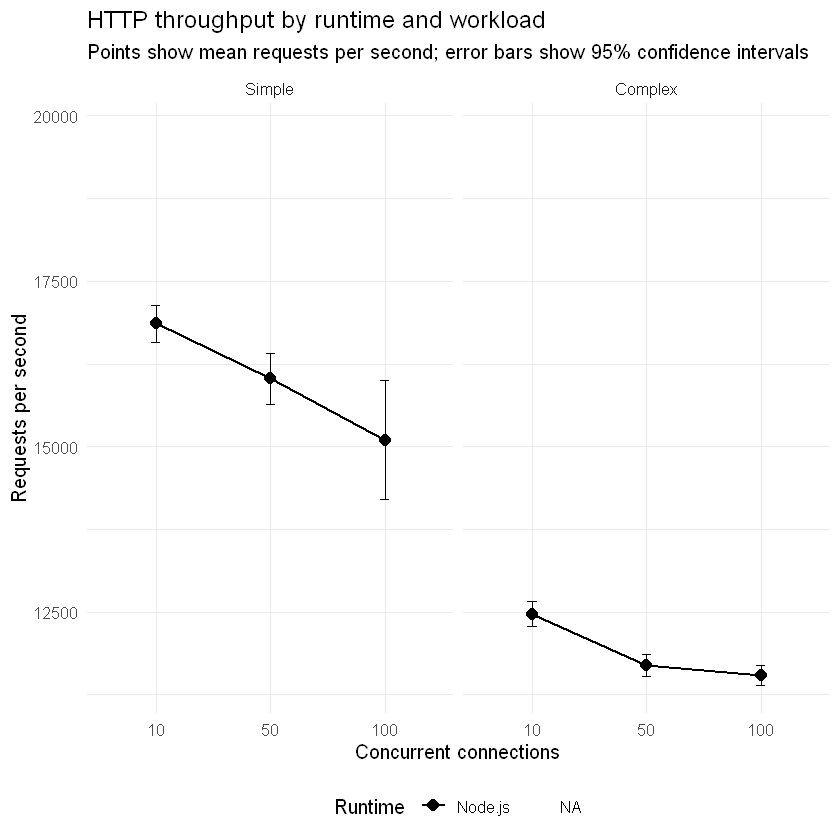

In [9]:
# throughput changes figure

http_throughput_plot <- ggplot(
  http_throughput_summary,
  aes(
    x = connections,
    y = mean_rps,
    group = runtime,
    shape = runtime,
    linetype = runtime
  )
) +
  geom_line(
    linewidth = 0.8
  ) +
  geom_point(
    size = 3
  ) +
  geom_errorbar(
    aes(
      ymin = ci_lower,
      ymax = ci_upper
    ),
    width = 0.08
  ) +
  facet_wrap(
    ~ workload
  ) +
  labs(
    title = "HTTP throughput by runtime and workload",
    subtitle = "Points show mean requests per second; error bars show 95% confidence intervals",
    x = "Concurrent connections",
    y = "Requests per second",
    shape = "Runtime",
    linetype = "Runtime"
  ) +
  theme_minimal(
    base_size = 12
  ) +
  theme(
    legend.position = "bottom"
  )

http_throughput_plot

In [10]:
http_final <- http_final |>
  mutate(
    runtime = factor(
      runtime,
      levels = c(
        "Node.js",
        "Bun",
        "Deno"
      )
    ),

    workload = factor(
      workload,
      levels = c(
        "simple",
        "complex"
      ),
      labels = c(
        "Simple",
        "Complex"
      )
    ),

    connections = factor(
      connections,
      levels = c(
        10,
        50,
        100
      )
    )
  )

In [11]:
table(
  http_final$runtime,
  useNA = "ifany"
)


Node.js     Bun    Deno    <NA> 
     60       0       0     120 

In [12]:
#Reloading HTTP from disk again
http_final <- read_csv(
  file.path(
    project_root,
    "data",
    "processed",
    "http",
    "http_final_combined.csv"
  ),
  show_col_types = FALSE
)

In [13]:
table(http_final$runtime, useNA = "ifany")


    Bun    Deno Node.js 
     60      60      60 

In [14]:
# applying name conversion

http_final <- http_final |>
  mutate(
    runtime = factor(
      runtime,
      levels = c(
        "Node.js",
        "Bun",
        "Deno"
      )
    ),

    workload = factor(
      workload,
      levels = c(
        "simple",
        "complex"
      ),
      labels = c(
        "Simple",
        "Complex"
      )
    ),

    connections = factor(
      connections,
      levels = c(
        10,
        50,
        100
      )
    )
  )

In [15]:
table(http_final$runtime, useNA = "ifany")


Node.js     Bun    Deno 
     60      60      60 

In [16]:
# HTTP throughput summary
http_throughput_summary <- http_final |>
  group_by(
    workload,
    connections,
    runtime
  ) |>
  summarise(
    n = n(),

    mean_rps = mean(
      requests_per_second
    ),

    median_rps = median(
      requests_per_second
    ),

    sd_rps = sd(
      requests_per_second
    ),

    se_rps = sd_rps / sqrt(n),

    ci_margin = qt(
      0.975,
      df = n - 1
    ) * se_rps,

    ci_lower = mean_rps - ci_margin,

    ci_upper = mean_rps + ci_margin,

    iqr_rps = IQR(
      requests_per_second
    ),

    min_rps = min(
      requests_per_second
    ),

    max_rps = max(
      requests_per_second
    ),

    .groups = "drop"
  )

http_throughput_summary

workload,connections,runtime,n,mean_rps,median_rps,sd_rps,se_rps,ci_margin,ci_lower,ci_upper,iqr_rps,min_rps,max_rps
<fct>,<fct>,<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Simple,10,Node.js,10,16859.00,16823.00,388.0141,122.70085,277.5686,16581.43,17136.57,444.7000,16192.27,17446.00
Simple,10,Bun,10,18049.56,18139.27,605.3813,191.43839,433.0637,17616.50,18482.63,584.6000,16671.87,18841.47
Simple,10,Deno,10,20040.02,19302.81,1594.3582,504.18033,1140.5351,18899.49,21180.56,2635.2300,17969.67,22207.34
Simple,50,Node.js,10,16025.44,15955.74,538.9635,170.43524,385.5513,15639.89,16410.99,477.7625,15065.34,16972.27
Simple,50,Bun,10,19256.60,19350.14,559.8659,177.04513,400.5039,18856.10,19657.10,909.7950,18428.14,20018.27
Simple,50,Deno,10,19018.88,18708.40,1110.9444,351.31146,794.7217,18224.16,19813.61,513.4000,17838.67,21345.47
Simple,100,Node.js,10,15099.96,15398.67,1259.9088,398.41816,901.2845,14198.68,16001.25,581.8350,11643.34,16009.87
Simple,100,Bun,10,17642.22,17766.67,755.7689,238.99510,540.6445,17101.57,18182.86,347.7675,15794.80,18437.20
Simple,100,Deno,10,19009.92,18394.53,1316.2685,416.24065,941.6018,18068.32,19951.52,2396.0700,17740.67,20878.54


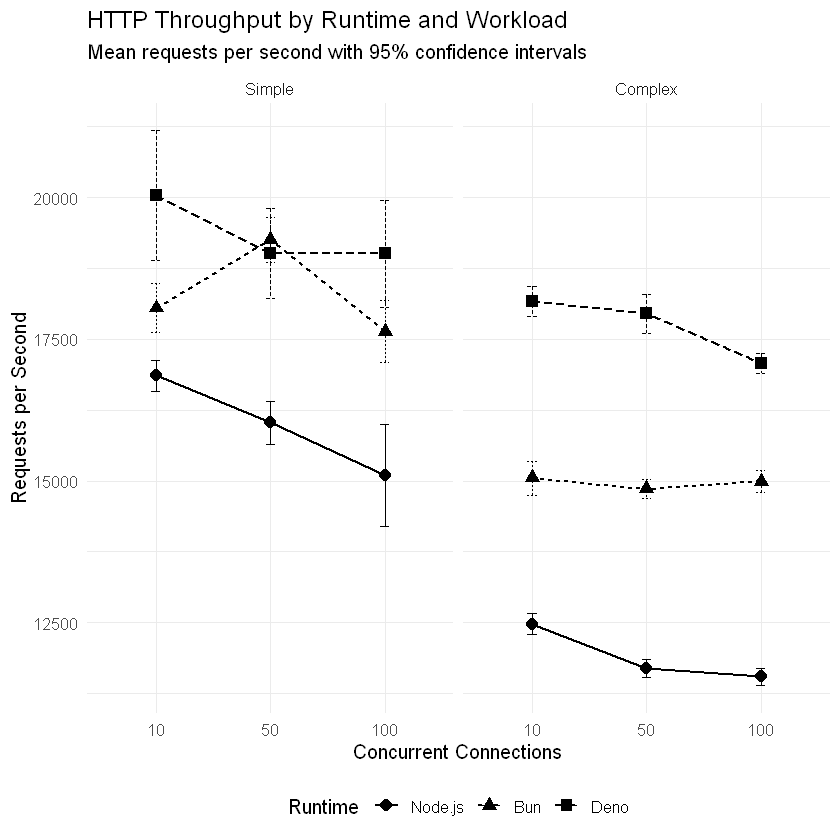

In [18]:
# http throughput graph 
http_throughput_plot <- ggplot(
  http_throughput_summary,
  aes(
    x = connections,
    y = mean_rps,
    group = runtime,
    shape = runtime,
    linetype = runtime
  )
) +
  geom_line(
    linewidth = 0.8
  ) +
  geom_point(
    size = 3
  ) +
  geom_errorbar(
    aes(
      ymin = ci_lower,
      ymax = ci_upper
    ),
    width = 0.08
  ) +
  facet_wrap(
    ~ workload
  ) +
  labs(
    title = "HTTP Throughput by Runtime and Workload",
    subtitle = "Mean requests per second with 95% confidence intervals",
    x = "Concurrent Connections",
    y = "Requests per Second",
    shape = "Runtime",
    linetype = "Runtime"
  ) +
  theme_minimal(
    base_size = 12
  ) +
  theme(
    legend.position = "bottom"
  )

http_throughput_plot

In [19]:
# save graph
http_figure_directory <- file.path(
  project_root,
  "results",
  "figures",
  "http"
)

dir.create(
  http_figure_directory,
  recursive = TRUE,
  showWarnings = FALSE
)

ggsave(
  filename = file.path(
    http_figure_directory,
    "http_throughput_final.png"
  ),
  plot = http_throughput_plot,
  width = 10,
  height = 6,
  dpi = 300
)

 check the normality of the paired throughput differences for each of the six HTTP conditions.

In [ ]:
# reload dataset

library(dplyr)
library(tidyr)
library(readr)

project_root <- if (dir.exists("data")) "." else ".."

http_final <- read_csv(
  file.path(
    project_root,
    "data",
    "processed",
    "http",
    "http_final_combined.csv"
  ),
  show_col_types = FALSE
)

http_final <- http_final |>
  mutate(
    runtime = factor(
      runtime,
      levels = c(
        "Node.js",
        "Bun",
        "Deno"
      )
    ),

    workload = factor(
      workload,
      levels = c(
        "simple",
        "complex"
      ),
      labels = c(
        "Simple",
        "Complex"
      )
    ),

    connections = factor(
      connections,
      levels = c(
        10,
        50,
        100
      )
    )
  )

In [6]:
table(http_final$runtime)


Node.js     Bun    Deno 
     60      60      60 

In [7]:
http_throughput_wide <- http_final |>
  select(
    workload,
    connections,
    repetition,
    runtime,
    requests_per_second
  ) |>
  pivot_wider(
    names_from = runtime,
    values_from = requests_per_second
  )

http_throughput_wide

workload,connections,repetition,Node.js,Bun,Deno
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
Simple,10,1,16192.27,17684.14,18875.34
Simple,10,2,16488.14,16671.87,18576.94
Simple,10,3,16764.00,17784.67,19204.94
Simple,10,4,16743.60,17901.47,21804.67
Simple,10,5,17446.00,18265.20,20957.87
Simple,10,6,17129.34,18420.67,22197.87
Simple,10,7,16966.00,18841.47,19300.67
Simple,10,8,16610.54,18580.94,22207.34
Simple,10,9,17368.14,18331.87,19304.94


In [8]:
# get differences in each observation throughput across runtimes

http_throughput_differences <- http_throughput_wide |>
  mutate(
    `Node.js - Bun` = `Node.js` - Bun,
    `Node.js - Deno` = `Node.js` - Deno,
    `Bun - Deno` = Bun - Deno
  ) |>
  select(
    workload,
    connections,
    repetition,
    `Node.js - Bun`,
    `Node.js - Deno`,
    `Bun - Deno`
  ) |>
  pivot_longer(
    cols = c(
      `Node.js - Bun`,
      `Node.js - Deno`,
      `Bun - Deno`
    ),
    names_to = "comparison",
    values_to = "difference"
  )

http_throughput_differences

workload,connections,repetition,comparison,difference
<fct>,<fct>,<dbl>,<chr>,<dbl>
Simple,10,1,Node.js - Bun,-1491.87
Simple,10,1,Node.js - Deno,-2683.07
Simple,10,1,Bun - Deno,-1191.20
Simple,10,2,Node.js - Bun,-183.73
Simple,10,2,Node.js - Deno,-2088.80
Simple,10,2,Bun - Deno,-1905.07
Simple,10,3,Node.js - Bun,-1020.67
Simple,10,3,Node.js - Deno,-2440.94
Simple,10,3,Bun - Deno,-1420.27


In [9]:
# normality check 
http_throughput_shapiro <- http_throughput_differences |>
  group_by(
    workload,
    connections,
    comparison
  ) |>
  summarise(
    W = unname(
      shapiro.test(difference)$statistic
    ),

    p_value = shapiro.test(difference)$p.value,

    .groups = "drop"
  )

http_throughput_shapiro

workload,connections,comparison,W,p_value
<fct>,<fct>,<chr>,<dbl>,<dbl>
Simple,10,Bun - Deno,0.9208422,0.364032985
Simple,10,Node.js - Bun,0.9568372,0.749295424
Simple,10,Node.js - Deno,0.8965548,0.200734993
Simple,50,Bun - Deno,0.7636126,0.005227872
Simple,50,Node.js - Bun,0.8870280,0.156959027
Simple,50,Node.js - Deno,0.8285997,0.032185900
Simple,100,Bun - Deno,0.8784512,0.125250787
Simple,100,Node.js - Bun,0.7244818,0.001745959
Simple,100,Node.js - Deno,0.9185444,0.344974863


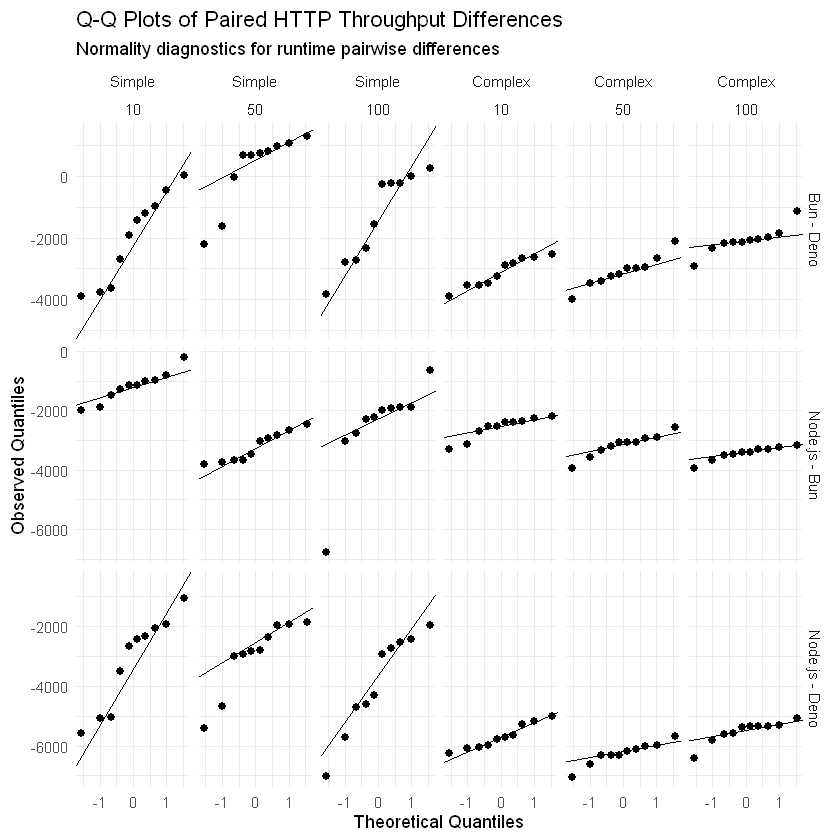

In [10]:
# Q-Q plot

http_throughput_qq <- ggplot(
  http_throughput_differences,
  aes(
    sample = difference
  )
) +
  stat_qq(
    size = 1.8
  ) +
  stat_qq_line() +
  facet_grid(
    comparison ~ workload + connections,
    scales = "free"
  ) +
  labs(
    title = "Q-Q Plots of Paired HTTP Throughput Differences",
    subtitle = "Normality diagnostics for runtime pairwise differences",
    x = "Theoretical Quantiles",
    y = "Observed Quantiles"
  ) +
  theme_minimal(
    base_size = 11
  )

http_throughput_qq

### HTTP Throughput Assumption Assessment

Normality of the paired runtime differences was assessed separately for each workload and connection condition using the Shapiro–Wilk test together with Q–Q plots.

The diagnostics indicated that the paired differences for **Simple/10**, **Complex/10**, and **Complex/50** were reasonably compatible with the normality assumption. These conditions will therefore be analysed using repeated-measures ANOVA.

In contrast, **Simple/50**, **Simple/100**, and **Complex/100** showed evidence of non-normality in at least one paired comparison, supported by visible departures in the corresponding Q–Q plots. These conditions will therefore be analysed using the non-parametric Friedman test.

No observations were removed on the basis of these diagnostics. Where unusual values were present, the analysis method was adapted rather than altering the validated benchmark data.

### Friedman Tests for HTTP Throughput

The paired-difference diagnostics indicated departures from normality for the Simple/50, Simple/100 and Complex/100 conditions. These conditions were therefore analysed using the Friedman test.

The Friedman test is a non-parametric repeated-measures test. It evaluates whether the three runtimes show systematically different performance ranks across the matched repetitions.

A statistically significant Friedman result indicates that at least one runtime differs from the others, but does not identify which runtime pairs are responsible for the difference. Where the omnibus test is significant, paired post-hoc comparisons will therefore be performed separately.

In [11]:
run_friedman <- function(data, workload_value, connections_value) {

  condition_data <- data |>
    filter(
      workload == workload_value,
      as.character(connections) == as.character(connections_value)
    )

  test <- friedman.test(
    requests_per_second ~ runtime | repetition,
    data = condition_data
  )

  n <- n_distinct(condition_data$repetition)
  k <- n_distinct(condition_data$runtime)

  tibble(
    workload = workload_value,
    connections = connections_value,

    chi_square = unname(
      test$statistic
    ),

    df = unname(
      test$parameter
    ),

    p_value = test$p.value,

    kendalls_w =
      unname(test$statistic) /
      (n * (k - 1))
  )
}


http_throughput_friedman <- bind_rows(

  run_friedman(
    http_final,
    "Simple",
    50
  ),

  run_friedman(
    http_final,
    "Simple",
    100
  ),

  run_friedman(
    http_final,
    "Complex",
    100
  )
)

http_throughput_friedman

workload,connections,chi_square,df,p_value,kendalls_w
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Simple,50,15.8,2,3.707435e-04,0.79
Simple,100,18.2,2,1.116658e-04,0.91
Complex,100,20.0,2,4.539993e-05,1.00


#### Friedman Test Results

The Friedman tests identified statistically significant differences in HTTP throughput between Node.js, Bun and Deno for all three non-parametric conditions.

- **Simple/50:** χ²(2) = 15.80, p < .001, Kendall's W = .79.
- **Simple/100:** χ²(2) = 18.20, p < .001, Kendall's W = .91.
- **Complex/100:** χ²(2) = 20.00, p < .001, Kendall's W = 1.00.

The effect sizes indicate strong to extremely strong consistency in runtime rankings. The Complex/100 condition produced a Kendall's W of 1.00, indicating identical runtime ordering across all ten matched repetitions.

Because the omnibus tests were significant, paired post-hoc comparisons are required to determine which runtime pairs differ.

this test only tells us that at least one rntime is different from another 

### Repeated-Measures ANOVA for HTTP Throughput

The paired-difference diagnostics indicated that the Simple/10, Complex/10 and Complex/50 conditions were reasonably compatible with the normality assumption. These conditions were therefore analysed using one-way repeated-measures ANOVA.

The repeated-measures design accounts for the fact that Node.js, Bun and Deno were measured within the same repetition blocks.

Sphericity was assessed using Mauchly's test. Where the assumption was violated, the Greenhouse–Geisser correction was applied to the ANOVA result.

In [12]:
install.packages("rstatix")
library(rstatix)

Installing package into 'C:/Users/folo47/AppData/Local/R/win-library/4.6'
(as 'lib' is unspecified)

also installing the dependency 'corrplot'




package 'corrplot' successfully unpacked and MD5 sums checked
package 'rstatix' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\folo47\AppData\Local\Temp\RtmpKWnz47\downloaded_packages


Warning message:
"package 'rstatix' was built under R version 4.6.1"

Attaching package: 'rstatix'


The following object is masked from 'package:stats':

    filter




In [13]:
run_rm_anova <- function(
  data,
  workload_value,
  connections_value
) {

  condition_data <- data |>
    filter(
      workload == workload_value,
      as.character(connections) ==
        as.character(connections_value)
    ) |>
    mutate(
      repetition = factor(repetition)
    )

  result <- condition_data |>
    anova_test(
      dv = requests_per_second,
      wid = repetition,
      within = runtime,
      effect.size = "ges"
    )

  list(
    full_result = result,
    anova_table = get_anova_table(
      result,
      correction = "auto"
    )
  )
}

In [14]:
anova_simple_10 <- run_rm_anova(
  http_final,
  "Simple",
  10
)

anova_complex_10 <- run_rm_anova(
  http_final,
  "Complex",
  10
)

anova_complex_50 <- run_rm_anova(
  http_final,
  "Complex",
  50
)

In [15]:
anova_simple_10$anova_table

anova_complex_10$anova_table

anova_complex_50$anova_table

,Effect,DFn,DFd,F,p,p<.05,ges
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,runtime,1.17,10.55,32.742,0.000107,*,0.652


,Effect,DFn,DFd,F,p,p<.05,ges
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,runtime,2,18,912.128,8.12e-19,*,0.979


,Effect,DFn,DFd,F,p,p<.05,ges
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,runtime,2,18,1113.513,1.37e-19,*,0.985


In [16]:
anova_simple_10$full_result$`Mauchly's Test for Sphericity`

anova_complex_10$full_result$`Mauchly's Test for Sphericity`

anova_complex_50$full_result$`Mauchly's Test for Sphericity`

,Effect,W,p,p<.05
,<chr>,<dbl>,<dbl>,<chr>
1,runtime,0.295,0.008,*


,Effect,W,p,p<.05
,<chr>,<dbl>,<dbl>,<chr>
1,runtime,0.917,0.707,


,Effect,W,p,p<.05
,<chr>,<dbl>,<dbl>,<chr>
1,runtime,0.834,0.484,


#### Repeated-Measures ANOVA Results

Repeated-measures ANOVA identified statistically significant runtime effects for all three conditions analysed parametrically.

- **Simple/10:** F(1.17, 10.55) = 32.74, p < .001, generalized η² = .652. Mauchly's test indicated a violation of sphericity, W = .295, p = .008, so the Greenhouse–Geisser corrected result was used.
- **Complex/10:** F(2, 18) = 912.13, p < .001, generalized η² = .979. Mauchly's test did not indicate a violation of sphericity, W = .917, p = .707.
- **Complex/50:** F(2, 18) = 1113.51, p < .001, generalized η² = .985. Mauchly's test did not indicate a violation of sphericity, W = .834, p = .484.

The results indicate strong runtime effects on HTTP throughput across all three conditions. Because each omnibus ANOVA was statistically significant, paired post-hoc comparisons are required to determine which runtime pairs differ.

### Pairwise Post-Hoc Comparisons for HTTP Throughput

All six omnibus tests identified statistically significant runtime effects on HTTP throughput. Pairwise post-hoc comparisons were therefore performed to identify which runtime pairs differed.

For conditions analysed using repeated-measures ANOVA, paired t-tests were used. For conditions analysed using the Friedman test, paired Wilcoxon signed-rank tests were used.

The three runtime comparisons were:

- Node.js vs Bun;
- Node.js vs Deno; and
- Bun vs Deno.

Because multiple pairwise tests were performed within the HTTP throughput metric family, Holm's sequential correction was applied to the combined set of post-hoc p-values.

In [26]:
runtime_pairs <- list(
  c("Node.js", "Bun"),
  c("Node.js", "Deno"),
  c("Bun", "Deno")
)

In [29]:
run_paired_t_tests <- function(
  data,
  workload_value,
  connections_value
) {

  condition_data <- data |>
    filter(
      workload == workload_value,
      as.character(connections) ==
        as.character(connections_value)
    )

  bind_rows(
    lapply(
      runtime_pairs,
      function(pair) {

        test_result <- stats::t.test(
          condition_data[[pair[1]]],
          condition_data[[pair[2]]],
          paired = TRUE
        )

        tibble(
          workload = workload_value,
          connections = connections_value,
          group1 = pair[1],
          group2 = pair[2],
          test_method = "Paired t-test",
          statistic = unname(test_result$statistic),
          df = unname(test_result$parameter),
          p_raw = test_result$p.value,
          mean_difference = mean(
            condition_data[[pair[1]]] -
              condition_data[[pair[2]]]
          )
        )
      }
    )
  )
}

In [ ]:
run_paired_wilcoxon <- function(
  data,
  workload_value,
  connections_value
) {

  condition_data <- data |>
    filter(
      workload == workload_value,
      as.character(connections) ==
        as.character(connections_value)
    )

  bind_rows(
    lapply(
      runtime_pairs,
      function(pair) {

        test_result <- stats::wilcox.test(
          condition_data[[pair[1]]],
          condition_data[[pair[2]]],
          paired = TRUE,
          exact = FALSE
        )

        tibble(
          workload = workload_value,
          connections = connections_value,
          group1 = pair[1],
          group2 = pair[2],
          test_method = "Wilcoxon signed-rank",
          statistic = unname(test_result$statistic),
          df = NA_real_,
          p_raw = test_result$p.value,
          mean_difference = mean(
            condition_data[[pair[1]]] -
              condition_data[[pair[2]]]
          )
        )
      }
    )
  )
}

In [30]:
posthoc_simple_10 <- run_paired_t_tests(
  http_throughput_wide,
  "Simple",
  10
)

posthoc_complex_10 <- run_paired_t_tests(
  http_throughput_wide,
  "Complex",
  10
)

posthoc_complex_50 <- run_paired_t_tests(
  http_throughput_wide,
  "Complex",
  50
)

In [31]:
posthoc_simple_10
posthoc_complex_10
posthoc_complex_50

workload,connections,group1,group2,test_method,statistic,df,p_raw,mean_difference
<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Simple,10,Node.js,Bun,Paired t-test,-7.268443,9,4.721728e-05,-1190.561
Simple,10,Node.js,Deno,Paired t-test,-6.481563,9,1.138687e-04,-3181.022
Simple,10,Bun,Deno,Paired t-test,-4.389161,9,1.747682e-03,-1990.461


workload,connections,group1,group2,test_method,statistic,df,p_raw,mean_difference
<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Complex,10,Node.js,Bun,Paired t-test,-22.04992,9,3.833691e-09,-2578.761
Complex,10,Node.js,Deno,Paired t-test,-43.25139,9,9.426328e-12,-5700.595
Complex,10,Bun,Deno,Paired t-test,-20.78745,9,6.456991e-09,-3121.834


workload,connections,group1,group2,test_method,statistic,df,p_raw,mean_difference
<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Complex,50,Node.js,Bun,Paired t-test,-26.59386,9,7.267243e-10,-3161.18
Complex,50,Node.js,Deno,Paired t-test,-53.12957,9,1.490007e-12,-6255.66
Complex,50,Bun,Deno,Paired t-test,-19.67989,9,1.046761e-08,-3094.48


In [34]:
posthoc_simple_50 <- run_paired_wilcoxon(
  http_throughput_wide,
  "Simple",
  50
)

posthoc_simple_100 <- run_paired_wilcoxon(
  http_throughput_wide,
  "Simple",
  100
)

posthoc_complex_100 <- run_paired_wilcoxon(
  http_throughput_wide,
  "Complex",
  100
)

posthoc_simple_50
posthoc_simple_100
posthoc_complex_100

workload,connections,group1,group2,test_method,statistic,df,p_raw,mean_difference
<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Simple,50,Node.js,Bun,Wilcoxon signed-rank,0,NA,0.005921537,-3231.156
Simple,50,Node.js,Deno,Wilcoxon signed-rank,0,NA,0.005921537,-2993.441
Simple,50,Bun,Deno,Wilcoxon signed-rank,35,NA,0.475532660,237.715


workload,connections,group1,group2,test_method,statistic,df,p_raw,mean_difference
<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Simple,100,Node.js,Bun,Wilcoxon signed-rank,0,NA,0.005921537,-2542.253
Simple,100,Node.js,Deno,Wilcoxon signed-rank,0,NA,0.005921537,-3909.959
Simple,100,Bun,Deno,Wilcoxon signed-rank,5,NA,0.024932456,-1367.706


workload,connections,group1,group2,test_method,statistic,df,p_raw,mean_difference
<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Complex,100,Node.js,Bun,Wilcoxon signed-rank,0,NA,0.005921537,-3442.881
Complex,100,Node.js,Deno,Wilcoxon signed-rank,0,NA,0.005921537,-5523.902
Complex,100,Bun,Deno,Wilcoxon signed-rank,0,NA,0.005921537,-2081.021


In [35]:
http_throughput_posthoc <- bind_rows(
  posthoc_simple_10,
  posthoc_simple_50,
  posthoc_simple_100,
  posthoc_complex_10,
  posthoc_complex_50,
  posthoc_complex_100
)

In [36]:
http_throughput_posthoc <- http_throughput_posthoc |>
  mutate(
    p_holm = p.adjust(
      p_raw,
      method = "holm"
    ),
    significant = ifelse(
      p_holm < 0.05,
      "Yes",
      "No"
    )
  ) |>
  arrange(
    workload,
    connections,
    group1,
    group2
  )

http_throughput_posthoc

workload,connections,group1,group2,test_method,statistic,df,p_raw,mean_difference,p_holm,significant
<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Complex,10,Bun,Deno,Paired t-test,-20.787455,9,6.456991e-09,-3121.834,9.039788e-08,Yes
Complex,10,Node.js,Bun,Paired t-test,-22.049917,9,3.833691e-09,-2578.761,5.750537e-08,Yes
Complex,10,Node.js,Deno,Paired t-test,-43.251393,9,9.426328e-12,-5700.595,1.602476e-10,Yes
Complex,50,Bun,Deno,Paired t-test,-19.679886,9,1.046761e-08,-3094.480,1.360789e-07,Yes
Complex,50,Node.js,Bun,Paired t-test,-26.593862,9,7.267243e-10,-3161.180,1.162759e-08,Yes
Complex,50,Node.js,Deno,Paired t-test,-53.129571,9,1.490007e-12,-6255.660,2.682013e-11,Yes
Complex,100,Bun,Deno,Wilcoxon signed-rank,0.000000,NA,5.921537e-03,-2081.021,5.329383e-02,No
Complex,100,Node.js,Bun,Wilcoxon signed-rank,0.000000,NA,5.921537e-03,-3442.881,5.329383e-02,No
Complex,100,Node.js,Deno,Wilcoxon signed-rank,0.000000,NA,5.921537e-03,-5523.902,5.329383e-02,No


In [37]:
#  checking if the exac twilcoxon test is appropriate i.e. exact=FALSE 

wilcoxon_exact_check <- http_throughput_differences |>
  filter(
    (workload == "Simple" & connections %in% c(50, 100)) |
    (workload == "Complex" & connections == 100)
  ) |>
  group_by(
    workload,
    connections,
    comparison
  ) |>
  summarise(
    zero_differences = sum(difference == 0),
    duplicated_absolute_differences =
      sum(duplicated(abs(difference))),
    .groups = "drop"
  )

wilcoxon_exact_check

workload,connections,comparison,zero_differences,duplicated_absolute_differences
<fct>,<fct>,<chr>,<int>,<int>
Simple,50,Bun - Deno,0,0
Simple,50,Node.js - Bun,0,0
Simple,50,Node.js - Deno,0,0
Simple,100,Bun - Deno,0,0
Simple,100,Node.js - Bun,0,0
Simple,100,Node.js - Deno,0,0
Complex,100,Bun - Deno,0,0
Complex,100,Node.js - Bun,0,0
Complex,100,Node.js - Deno,0,0


In [38]:
# rewriting wilcoxon function 

run_paired_wilcoxon <- function(
  data,
  workload_value,
  connections_value
) {

  condition_data <- data |>
    filter(
      workload == workload_value,
      as.character(connections) ==
        as.character(connections_value)
    )

  bind_rows(
    lapply(
      runtime_pairs,
      function(pair) {

        test_result <- stats::wilcox.test(
          condition_data[[pair[1]]],
          condition_data[[pair[2]]],
          paired = TRUE,
          exact = TRUE
        )

        tibble(
          workload = workload_value,
          connections = connections_value,
          group1 = pair[1],
          group2 = pair[2],
          test_method = "Wilcoxon signed-rank",
          statistic = unname(test_result$statistic),
          df = NA_real_,
          p_raw = test_result$p.value,
          mean_difference = mean(
            condition_data[[pair[1]]] -
            condition_data[[pair[2]]]
          )
        )
      }
    )
  )
}

In [39]:
posthoc_simple_50 <- run_paired_wilcoxon(
  http_throughput_wide, "Simple", 50
)

posthoc_simple_100 <- run_paired_wilcoxon(
  http_throughput_wide, "Simple", 100
)

posthoc_complex_100 <- run_paired_wilcoxon(
  http_throughput_wide, "Complex", 100
)

In [40]:
http_throughput_posthoc <- bind_rows(
  posthoc_simple_10,
  posthoc_simple_50,
  posthoc_simple_100,
  posthoc_complex_10,
  posthoc_complex_50,
  posthoc_complex_100
) |>
  mutate(
    p_holm = p.adjust(
      p_raw,
      method = "holm"
    ),
    significant = ifelse(
      p_holm < 0.05,
      "Yes",
      "No"
    )
  ) |>
  arrange(
    workload,
    connections,
    group1,
    group2
  )

http_throughput_posthoc

workload,connections,group1,group2,test_method,statistic,df,p_raw,mean_difference,p_holm,significant
<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Complex,10,Bun,Deno,Paired t-test,-20.787455,9,6.456991e-09,-3121.834,9.039788e-08,Yes
Complex,10,Node.js,Bun,Paired t-test,-22.049917,9,3.833691e-09,-2578.761,5.750537e-08,Yes
Complex,10,Node.js,Deno,Paired t-test,-43.251393,9,9.426328e-12,-5700.595,1.602476e-10,Yes
Complex,50,Bun,Deno,Paired t-test,-19.679886,9,1.046761e-08,-3094.480,1.360789e-07,Yes
Complex,50,Node.js,Bun,Paired t-test,-26.593862,9,7.267243e-10,-3161.180,1.162759e-08,Yes
Complex,50,Node.js,Deno,Paired t-test,-53.129571,9,1.490007e-12,-6255.660,2.682013e-11,Yes
Complex,100,Bun,Deno,Wilcoxon signed-rank,0.000000,NA,1.953125e-03,-2081.021,1.757812e-02,Yes
Complex,100,Node.js,Bun,Wilcoxon signed-rank,0.000000,NA,1.953125e-03,-3442.881,1.757812e-02,Yes
Complex,100,Node.js,Deno,Wilcoxon signed-rank,0.000000,NA,1.953125e-03,-5523.902,1.757812e-02,Yes
